# MSDS 430 Module 6 Python Assignment

<div class="alert alert-block alert-warning"><b>In this assignment you will read through the notebook and complete the exercises. Once you are satisfied with the results, submit your notebook and html file to Canvas. Your files should include all output, i.e. run each cell and save your file before submitting.</b></div>

<div class="alert alert-block alert-info"> 
    <b>Research project problem statement (continued from Module 5):</b>  
    
There are a number of steps to our questions about this data:
- First, we need to become familiar with which states perform best and worst in each category.  
- Next, we want to examine how population, population density, and budgets relate to any of the categories.  
- <u>One hypothesis</u> to test is that states with a higher 5-year population growth rate will have higher `Economy` scores. The reasoning is that people tend to move to states with stronger job growth.  
- <u>Another hypothesis</u> is that larger states by area will perform better in the `Natural Environment` category, based on the idea that more land area results in less pollution.  
- <u>The final hypothesis</u> is that more densely populated states will have lower scores in the `Crime` category, based on the assumption that higher population density can lead to more crime-related issues.
    
<b>Objectives:</b>

- Read the clean file from Module 5 into a dataframe
- Use Seaborn pairplots to investigate each field closer and to inspect the relationships between fields
- Use a correlation matrix to look for relationships amoung variables
- Create new column in dataframe
- Learn how to handle a skewed variable
- Subset data by rows (certain years, certain countries)
- Subset data by columns (only include some columns in a new dataframe)
- Learn various ways to plot data using Seaborn and Plotly
- Create derived variables to add to the dataframe
- seaborn pairplot (with hue)
- groupby with aggregators
- rankings and groupings with `cut` and `qcut`

</div>

<div class="alert alert-block alert-danger"><b>Reminder: In all of the problems you will see <font color=black>#ToDo</font> statements added as comments on the code cell provided. You will want to be sure to complete each of these as indicated to avoid losing points.</b></div>

In [1]:
# if you have not used plotly before, uncomment this cell and run once
# !pip install plotly

In [2]:
# Set up notebook to display multiple outputs in one cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import pandas as pd
import numpy as np
from scipy.stats import spearmanr

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

%matplotlib inline

In [3]:
# HTML exports of plotly charts were not rendering so adding this code chunk at the top
import plotly.io as pio
pio.renderers.default = "notebook_connected"

### Budget columns with zeros

Remember we left it until this week to figure out how to handle the budget columns with zeros.

In [4]:
# Read in budget file
dollars = pd.read_csv('dollar_final.csv')
dollars.info()
dollars.head()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   State      50 non-null     str    
 1   ELSED_TOT  50 non-null     float64
 2   HGRED_TOT  50 non-null     float64
 3   TANF_TOT   50 non-null     float64
 4   OTCA_TOT   50 non-null     float64
 5   MCAID_TOT  50 non-null     float64
 6   CORR_TOT   50 non-null     float64
 7   TRANS_TOT  50 non-null     float64
 8   OTHER_TOT  50 non-null     float64
 9   ELCAP TOT  50 non-null     int64  
 10  HEDCP_TOT  50 non-null     int64  
 11  CORCP_TOT  50 non-null     int64  
 12  TRCAP_TOT  50 non-null     int64  
 13  HSCAP_TOT  50 non-null     int64  
 14  ENVCP_TOT  50 non-null     int64  
 15  OTHCP_TOT  50 non-null     int64  
dtypes: float64(8), int64(7), str(1)
memory usage: 6.8 KB


,State,ELSED_TOT,HGRED_TOT,TANF_TOT,OTCA_TOT,MCAID_TOT,CORR_TOT,TRANS_TOT,OTHER_TOT,ELCAP TOT,HEDCP_TOT,CORCP_TOT,TRCAP_TOT,HSCAP_TOT,ENVCP_TOT,OTHCP_TOT
0,Alabama,11296.0,7763.0,26.0,0.0,9687.0,1020.0,2083.0,7326.0,506,205,0,749,0,1,80
1,Alaska,1963.0,1006.0,22.0,103.0,2508.0,525.0,2648.0,6871.0,56,37,8,1851,63,310,836
2,Arizona,11120.0,9377.0,181.0,23.0,25668.0,3153.0,5652.0,41034.0,358,73,115,1186,0,13,19
3,Arkansas,4839.0,4678.0,100.0,536.0,9052.0,501.0,2180.0,11449.0,0,11,6,981,0,0,93
4,California,82522.0,28918.0,7904.0,6511.0,157272.0,19032.0,34911.0,157080.0,5,786,98,11904,0,0,1220


### Closer inspection of State budget file


| Column | Definition |
| --- | ---|
| ELSED_TOT | Elementary & Secondary Education Total Funds |
| HGRED_TOT | Higher Education Total Funds |
| TANF_TOT | Temporary Assistance for Needy Families Total Funds |
| OTCA_TOT | Other Cash Assistance Total Funds |
| MCAID_TOT | Medicaid Total Funds |
| CORR_TOT | Corrections Total Funds |
| TRANS_TOT | Transportation Total Funds |
| OTHER_TOT | All Other Total Funds |
| ELCAP_TOT | Elementary & Secondary Education Capital Total Funds |
| HEDCP_TOT | Corrections Capital General Funds |
| CORCP_TOT | Corrections Capital Total Funds |
| TRCAP_TOT | Transportation Capital Total Funds |
| HSCAP_TOT | Housing Capital Total Funds |
| ENVCP_TOT | Enviromental Capital Total Funds |
| OTHCP_TOT | All Other Capital Total Funds |


Recall that some columns have zeros. Let's remind ourselves which columns those are.

In [5]:
dollars.describe()

,ELSED_TOT,HGRED_TOT,TANF_TOT,OTCA_TOT,MCAID_TOT,CORR_TOT,TRANS_TOT,OTHER_TOT,ELCAP TOT,HEDCP_TOT,CORCP_TOT,TRCAP_TOT,HSCAP_TOT,ENVCP_TOT,OTHCP_TOT
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,11559.132137,5348.700069,378.972000,260.086000,18280.434000,1637.921220,4931.829600,18890.293854,97.520000,330.800000,56.440000,2243.600000,74.920000,204.940000,522.420000
std,14058.032943,5448.514175,1152.099577,970.536318,25571.339165,2766.810709,5896.736581,25497.856995,195.197466,486.460142,117.719514,3467.085684,219.503042,566.226659,645.399926
min,912.000000,169.000000,0.000000,0.000000,765.000000,136.000000,152.000000,2180.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3573.500000,1555.500000,29.000000,0.000000,4731.750000,437.250000,1663.250000,5826.500000,0.000000,29.500000,4.250000,206.750000,0.000000,0.000000,81.500000
50%,7641.500000,3737.500000,111.000000,23.000000,12164.500000,925.000000,2860.000000,10369.000000,4.000000,126.000000,20.000000,1029.000000,0.000000,13.500000,310.500000
75%,14296.250000,7942.250000,247.500000,115.500000,19583.750000,1741.750000,6030.500000,22449.000000,57.500000,464.500000,55.000000,2680.000000,1.750000,123.500000,770.750000
max,82522.000000,28918.000000,7904.000000,6511.000000,157272.000000,19032.000000,34911.000000,157080.000000,1034.000000,2708.000000,647.000000,16260.000000,1113.000000,3490.000000,3520.000000


In [6]:
# Determine which columns have a zero min
zero_columns = []
for col in dollars.columns:
    if dollars[col].min() == 0:
        zero_columns.append(col)
        
zero_columns

['TANF_TOT',
 'OTCA_TOT',
 'ELCAP TOT',
 'HEDCP_TOT',
 'CORCP_TOT',
 'TRCAP_TOT',
 'HSCAP_TOT',
 'ENVCP_TOT',
 'OTHCP_TOT']

In [7]:
# Alternatively, code with a list comprehension
zero_columns1 = [col for col in dollars.columns if dollars[col].min() == 0]
zero_columns1

['TANF_TOT',
 'OTCA_TOT',
 'ELCAP TOT',
 'HEDCP_TOT',
 'CORCP_TOT',
 'TRCAP_TOT',
 'HSCAP_TOT',
 'ENVCP_TOT',
 'OTHCP_TOT']

Next we'll determine the rows where at least on column contains a 0. In a pandas dataframe, axes represent the different dimensions of the data. Axis 0 represents the rows of the dataframe, i.e. the data along the vertical axis. Axis 1 represents the columns of the dataframe, i.e. the data along the horizontal axis. The following code determines the rows where at least one column contains a 0.

In [8]:
# Determine rows where at least one column contains a 0
mask = dollars[zero_columns].min(axis=1) == 0
dollars[mask]

,State,ELSED_TOT,HGRED_TOT,TANF_TOT,OTCA_TOT,MCAID_TOT,CORR_TOT,TRANS_TOT,OTHER_TOT,ELCAP TOT,HEDCP_TOT,CORCP_TOT,TRCAP_TOT,HSCAP_TOT,ENVCP_TOT,OTHCP_TOT
0,Alabama,11296.000000,7763.00000,26.0,0.0,9687.0,1020.000,2083.00,7326.000000,506,205,0,749,0,1,80
2,Arizona,11120.000000,9377.00000,181.0,23.0,25668.0,3153.000,5652.00,41034.000000,358,73,115,1186,0,13,19
3,Arkansas,4839.000000,4678.00000,100.0,536.0,9052.0,501.000,2180.00,11449.000000,0,11,6,981,0,0,93
4,California,82522.000000,28918.00000,7904.0,6511.0,157272.0,19032.000,34911.00,157080.000000,5,786,98,11904,0,0,1220
5,Colorado,7485.000000,5203.00000,197.0,87.0,13812.0,1127.000,1793.00,9483.000000,6,257,73,1,0,7,251
7,Delaware,3740.000000,595.00000,26.0,6.0,3301.0,447.000,1180.00,6797.000000,191,80,8,721,0,22,169
8,Florida,19057.000000,8969.00000,124.0,21.0,34486.0,4059.000,15418.00,36500.000000,430,879,23,14469,0,3490,2338
9,Georgia,15768.000000,11306.00000,370.0,0.0,14133.0,2701.000,5634.00,12968.000000,257,638,647,0,0,14,674
10,Hawaii,3078.000000,816.00000,21.0,27.0,3202.0,402.000,1861.00,10750.000000,0,122,0,672,0,15,788
11,Idaho,3518.000000,1222.00000,6.0,10.0,4073.0,423.000,1620.00,3740.000000,0,27,5,1077,0,0,275


### What to do about columns with zero values?

Note that the zero values are either missing values or that state did not have a budget in the category. We do not know why it is zero.  And we have no way to impute a reasonable value. It is better for us to drop the columns that have zeros and only use the columns that have a value for every state.

In [9]:
# Check shape before dropping columns
dollars.shape

# Drop the zero columns
dollars = dollars.drop(columns = zero_columns)

# Check shape after dropping columns with 0
dollars.shape

(50, 16)

(50, 7)

Next we get the columns we need for a seaborn pairplot. The state column is not needed for this.

In [10]:
col = dollars.columns[1:]
col

Index(['ELSED_TOT', 'HGRED_TOT', 'MCAID_TOT', 'CORR_TOT', 'TRANS_TOT',
       'OTHER_TOT'],
      dtype='str')

### Seaborn pairplots

__[Seaborn pairplots](https://seaborn.pydata.org/generated/seaborn.pairplot.html)__

The Seaborn pairplot will show a histogram of each variable and a scatterplot of each combination of variables. These views allow you to see the distribution of each individual field and also how each field interacts with the other fields.

In the example below we are showing the remaining budget columns. There are a few things of note in the plots:
- The plots between the pairs of data are unremarkable where they all look very similar.
- It appears that there are always a few outliers which we know to be the 3 larger states.
- It appears that for every pair there is a positive relationship where as one budget increases in value, the other budget also increases.
- **Most important** is what is shown in the diagonal on the histogram where all variables appear to be `skewed`.

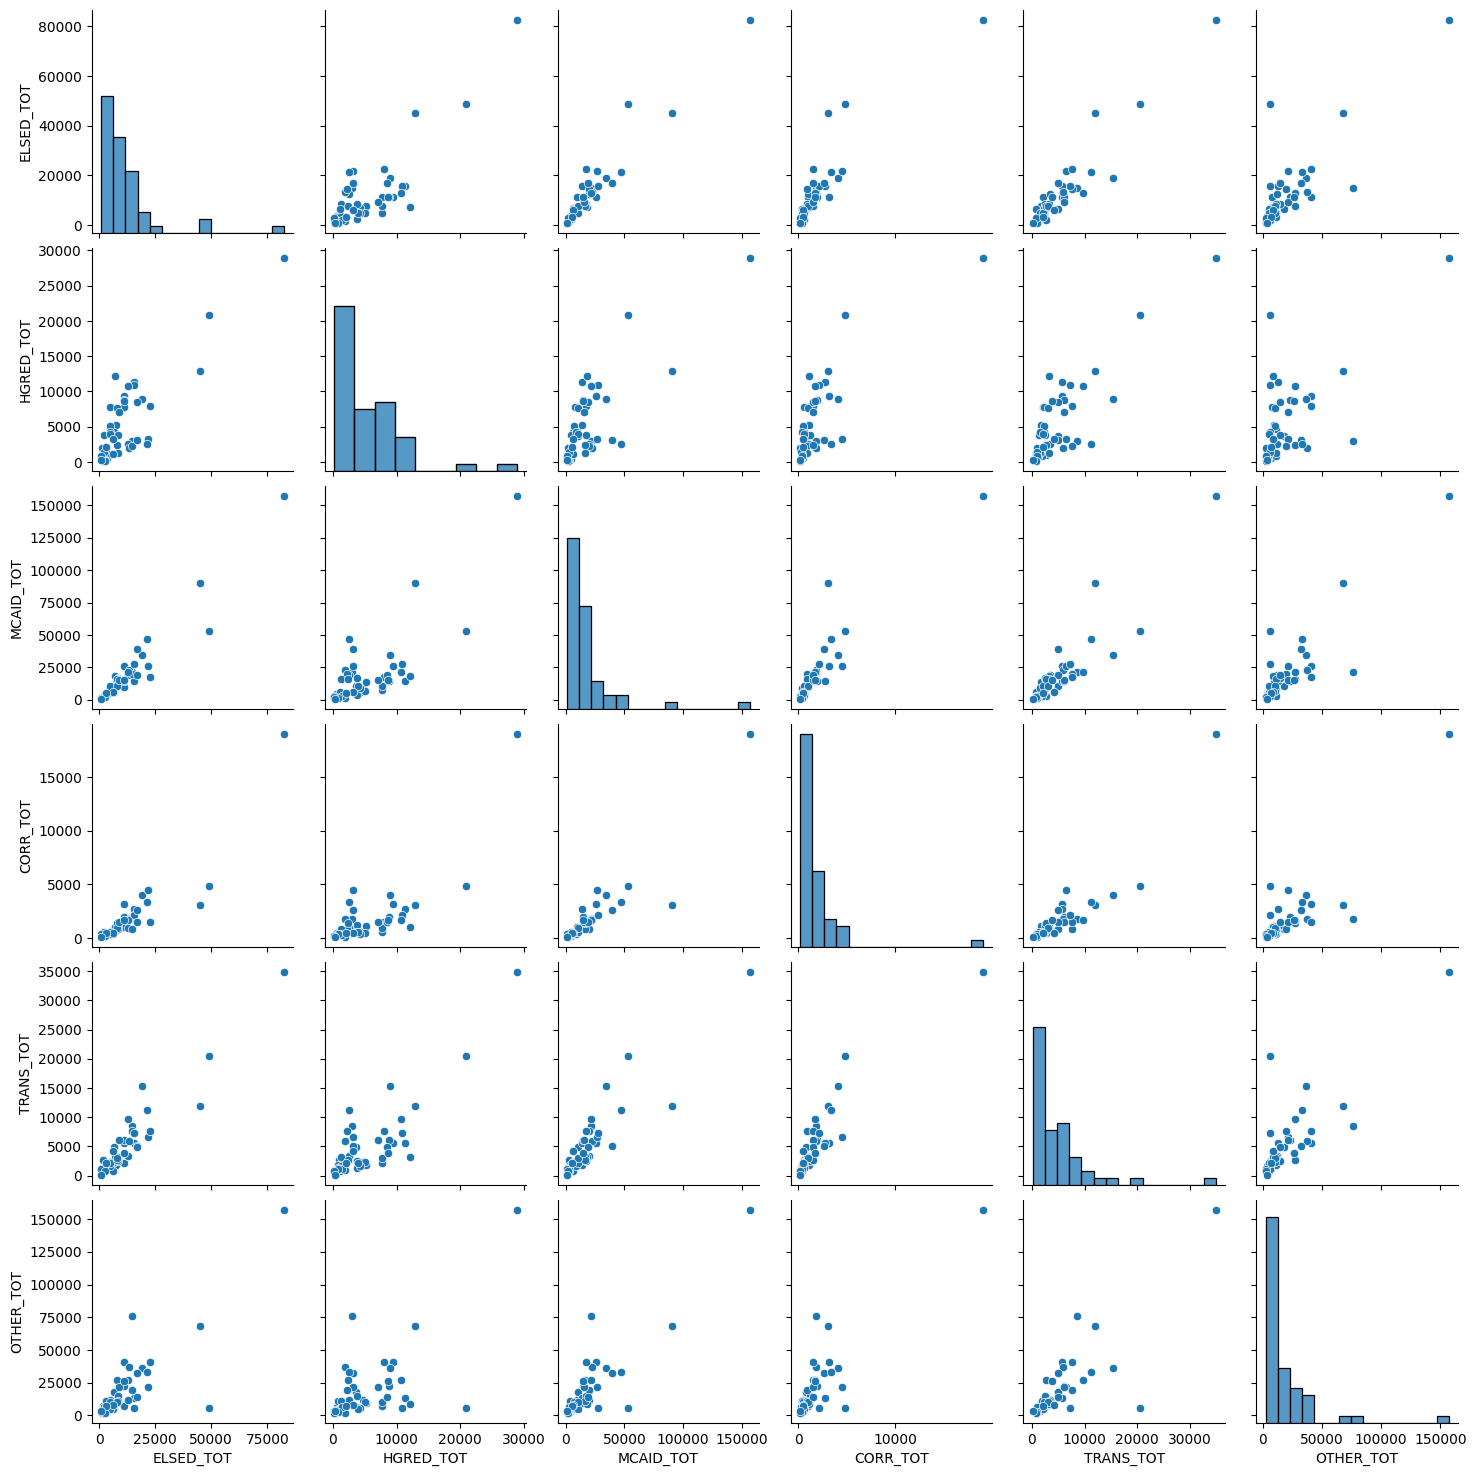

In [11]:
# Pairplots  
sns.pairplot(dollars[col])

### Skewed data

- **Negative skew (aka left skewed)**: the left tail is longer and the mass of the distribution is on the right of plot which results in a right leaning curve.
- **Positive skew (aka right skewed)**: the right tail is longer and the mass of the distribution is on the left of the plot which results in a left leaning curve.
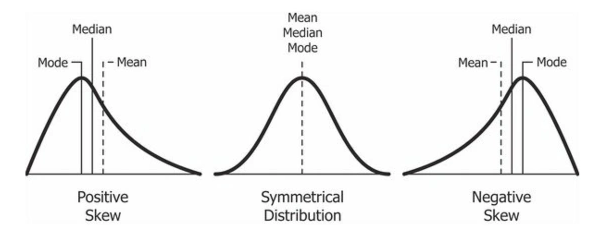

Source: __[What is Skewness?](https://www.analyticsvidhya.com/blog/2020/07/what-is-skewness-statistics/)__

More information on the `skew` method for pandas can be found here: __[pandas skew](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.skew.html)__

In [12]:
dollars.skew(numeric_only = True)

ELSED_TOT    3.343595
HGRED_TOT    2.215651
MCAID_TOT    3.911170
CORR_TOT     5.319212
TRANS_TOT    3.279018
OTHER_TOT    3.745403
dtype: float64

### Handling skewed data

Data is considered to be skewed when the skew value is +3 or -3. Numpy's `log` and `square` function are two ways in which skewed values can be adjusted.

- `log` is typically used for postively skewed data
- `square` is typically used for negatively skewed data
- Note that there are other alternatives for normalizing data beyond log and square

In [13]:
# Investigate how log reduces the skew
corrtotLog = np.log(dollars['CORR_TOT'])
corrtotLog.skew()

np.float64(0.3814184778056457)

### When to handle the skewed values

It is not vital in EDA processes that you handle the skewness of a column. But as you move on to build models, you need to be aware of the underlying assumptions about the data. For example, linear models assume that the distribution of both the independent variable and the target variable are similar. 

### Skewed Data and Correlation

- Outliers, which are common in skewed data, can pull the correlation coefficient in a particular direction, making it appear stronger or weaker than it actually is.
- Skewed data can artificially inflate or deflate the correlation coefficient, making it difficult to accurately assess the true strength and direction of the relationship between variables.

### Types of correlation

Different types of correlations have different underlying assumptions. You will choose the type of correlation that best fits your data.
- `Pearson` **this is the default**:
    - measures the linear relationship between two continuous variables
    - assumes both variables are normally distributed
- `Spearman rank`:
    - measures the position between two variables (do they increase or decrease at same pace?)
    - does not assume normality
    - can be used with ordinal data
- `Kendall Tau`
    - similar to Spearman but less sensitive to outliers
    
Reference: __[pandas corr](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html)__

,ELSED_TOT,HGRED_TOT,MCAID_TOT,CORR_TOT,TRANS_TOT,OTHER_TOT
ELSED_TOT,1.000000,0.677663,0.939304,0.920864,0.890516,0.767011
HGRED_TOT,0.677663,1.000000,0.660760,0.727124,0.669068,0.507863
MCAID_TOT,0.939304,0.660760,1.000000,0.919040,0.889556,0.788043
CORR_TOT,0.920864,0.727124,0.919040,1.000000,0.896279,0.794862
TRANS_TOT,0.890516,0.669068,0.889556,0.896279,1.000000,0.808884
OTHER_TOT,0.767011,0.507863,0.788043,0.794862,0.808884,1.000000


<Axes: >

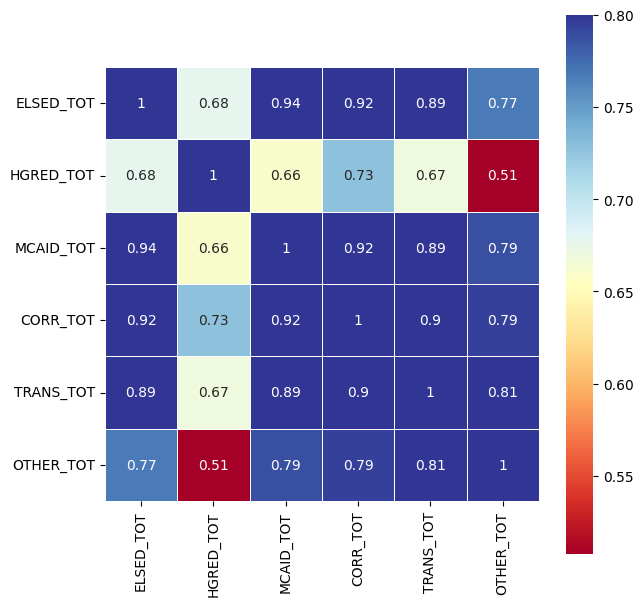

In [14]:
df_corr = dollars[col]

# Creates a correlation matrix
corrmat = df_corr.corr(method = 'spearman')
# Corrmat = df_corr.corr(method = 'pearson')
corrmat

# Heatmap of correlation matrix
f, ax = plt.subplots(figsize = (7,7))
sns.heatmap(corrmat, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )

### Columns to keep and why

Note that columns that are highly correlated (> .7), tend to be representing close to the same values. Depending on your data topic and the need for absolute accuracy, highly correlated columns can be seen as redundant data.  Also note that highly accurate research, as in the medical field, will require a different set of rules for what to include/exclude.

- ELSED - HS/elem school 
    - highly correlated with most fields
- HGRED - higher ed 
    - only has moderate correlation with ELSED
- TOTAL - other total
    - only has moderate correlation with HGRED
    
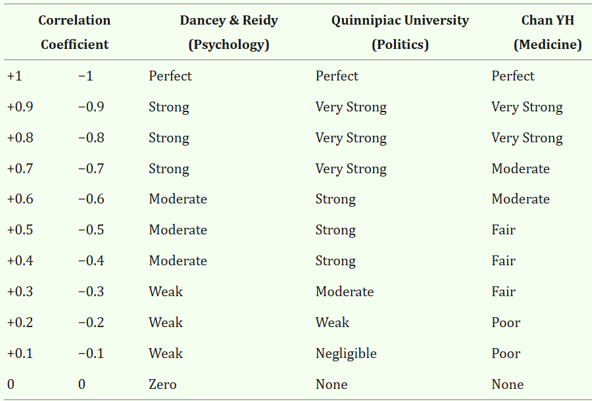

Reference: __[Guide to Correlation](https://pmc.ncbi.nlm.nih.gov/articles/PMC6107969/)__

Next we read in the final merged data from Module 5.

In [15]:
df = pd.read_csv('merged_final.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             50 non-null     str    
 1   Health Care       50 non-null     int64  
 2   Education         50 non-null     int64  
 3   Economy           50 non-null     int64  
 4   Infrastructure    50 non-null     int64  
 5   Opportunity       50 non-null     int64  
 6   Fiscal Stability  50 non-null     int64  
 7   Crime             50 non-null     int64  
 8   Environment       50 non-null     int64  
 9   Population        50 non-null     int64  
 10  5YR Pop Delta     50 non-null     int64  
 11  Total SQ Miles    50 non-null     int64  
 12  Land SQ Miles     50 non-null     int64  
 13  ELSED_TOT         50 non-null     float64
 14  HGRED_TOT         50 non-null     float64
 15  TANF_TOT          50 non-null     float64
 16  OTCA_TOT          50 non-null     float64
 17  MCAID_TOT 

<div class="alert alert-block alert-success"><b>Problem 1 (4 pts.)</b>: 
    
Drop all TOT columns except for the three listed below. When you drop the columns, create a new dataframe called `merged`:

- ELSED_TOT
- HGRED_TOT
- OTHER_TOT
    
Show the info of the `merged` dataframe.

</div>

In [16]:
#ToDo: Drop columns from df into a new dataframe called 'merged'
tot_cols_to_drop = [col for col in df.columns if 'TOT' in col and col not in ['ELSED_TOT', 'HGRED_TOT', 'OTHER_TOT']]
merged = df.drop(columns=tot_cols_to_drop)

#ToDo: Show new merged dataframe with info
merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             50 non-null     str    
 1   Health Care       50 non-null     int64  
 2   Education         50 non-null     int64  
 3   Economy           50 non-null     int64  
 4   Infrastructure    50 non-null     int64  
 5   Opportunity       50 non-null     int64  
 6   Fiscal Stability  50 non-null     int64  
 7   Crime             50 non-null     int64  
 8   Environment       50 non-null     int64  
 9   Population        50 non-null     int64  
 10  5YR Pop Delta     50 non-null     int64  
 11  Total SQ Miles    50 non-null     int64  
 12  Land SQ Miles     50 non-null     int64  
 13  ELSED_TOT         50 non-null     float64
 14  HGRED_TOT         50 non-null     float64
 15  OTHER_TOT         50 non-null     float64
 16  Pop Density       50 non-null     float64
dtypes: float64

<div class="alert alert-block alert-success"><b>Problem 2 (3 pts.)</b>: Rename the three TOT columns as shown below.

- ELSED_TOT - to `K-12 Funds`
- HGRED_TOT - to `Higher Ed Funds`
- OTHER_TOT - to `Other Funds`
    
Show the info of the `merged` dataframe.

</div>

In [17]:
#ToDo: Rename columns
merged = merged.rename(columns={'ELSED_TOT': 'K-12 Funds', 'HGRED_TOT': 'Higher Ed Funds', 'OTHER_TOT': 'Other Funds'})

#ToDo: Display the info of merged
merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             50 non-null     str    
 1   Health Care       50 non-null     int64  
 2   Education         50 non-null     int64  
 3   Economy           50 non-null     int64  
 4   Infrastructure    50 non-null     int64  
 5   Opportunity       50 non-null     int64  
 6   Fiscal Stability  50 non-null     int64  
 7   Crime             50 non-null     int64  
 8   Environment       50 non-null     int64  
 9   Population        50 non-null     int64  
 10  5YR Pop Delta     50 non-null     int64  
 11  Total SQ Miles    50 non-null     int64  
 12  Land SQ Miles     50 non-null     int64  
 13  K-12 Funds        50 non-null     float64
 14  Higher Ed Funds   50 non-null     float64
 15  Other Funds       50 non-null     float64
 16  Pop Density       50 non-null     float64
dtypes: float64

<div class="alert alert-block alert-success"><b>Problem 3 (4 pts.)</b>: 
    
1. Create a new column called `Overall` determined from an overall average score per state.
2. Show the top 5 states based on the overall score. Remember that the higher the `Overall` score, the better rating for the state.
3. Show the bottom 5 states based on the overall score.

Hint: `Overall` = (sum of all 8 state scores)/8 - round to 2 decimal places OR you can use mean().

</div>

<div class="alert alert-block alert-success"><b>Problem 3 (part 1)</b>: 
    
Create a new column called `Overall` determined from an overall average score per state.
</div>

In [18]:
#ToDo: Calculate a new field in merged called Overall
merged['Overall'] = merged[['Health Care', 'Education', 'Economy', 'Infrastructure', 'Opportunity',
       'Fiscal Stability', 'Crime', 'Environment']].mean(axis=1).round(2)

<div class="alert alert-block alert-success"><b>Problem 3 (parts 2 and 3)</b>: 
    
- Show the top 5 states based on the overall score. Remember that the higher the `Overall` score, the better rating for the state.
- Show the bottom 5 states based on the overall score.

</div>

In [19]:
#ToDo: Display the top 5 states
display(merged.nlargest(5, 'Overall'))

#ToDo: Display the bottom 5 states
display(merged.nsmallest(5, 'Overall'))

,State,Health Care,Education,Economy,Infrastructure,Opportunity,Fiscal Stability,Crime,Environment,Population,5YR Pop Delta,Total SQ Miles,Land SQ Miles,K-12 Funds,Higher Ed Funds,Other Funds,Pop Density,Overall
0,Utah,37,49,48,48,33,45,42,5,3503613,219536,84897,82170,6217.0,3216.0,8238.0,42.638591,38.38
1,New Hampshire,38,42,44,29,41,13,50,43,1409032,30276,9349,8953,1666.0,194.0,3076.0,157.380990,37.50
2,Nebraska,26,37,32,47,32,48,34,42,2005465,42078,77348,76824,2339.0,3828.0,6365.0,26.104668,37.25
3,Minnesota,35,34,25,42,39,44,29,49,5793151,82416,86936,79627,14620.0,2250.0,19503.0,72.753601,37.12
4,Idaho,33,33,49,36,37,42,39,22,2001619,152204,83569,82643,3518.0,1222.0,3740.0,24.220067,36.38


,State,Health Care,Education,Economy,Infrastructure,Opportunity,Fiscal Stability,Crime,Environment,Population,5YR Pop Delta,Total SQ Miles,Land SQ Miles,K-12 Funds,Higher Ed Funds,Other Funds,Pop Density,Overall
49,Louisiana,5,4,2,2,7,10,1,2,4597740,-54561,52378,43204,8388.0,3779.0,14747.0,106.419313,4.12
48,New Mexico,13,1,6,7,15,18,3,19,2130256,11650,121590,121298,4890.0,4269.0,5806.0,17.562169,10.25
47,Mississippi,1,16,1,3,16,6,26,31,2943045,-15491,48432,46923,4998.0,5069.0,10600.0,62.720734,12.50
46,Arkansas,4,13,11,9,22,24,2,16,3088354,73808,53179,52035,4839.0,4678.0,11449.0,59.351475,12.62
44,Alaska,24,5,5,5,30,30,7,7,740133,7116,665384,570641,1963.0,1006.0,6871.0,1.297020,14.12


<div class="alert alert-block alert-success"><b>Problem 4 (4 pts.)</b>: 
    
Run a `spearman` rank correlation on all numeric fields in the `merged` dataframe. Remember to make the `figsize` large enough so that the matrix numbers are readable.

Optional to print out a diagonal correlation matrix which just makes it easier to read: __[seaborn pairwise correlation](https://seaborn.pydata.org/examples/many_pairwise_correlations.html)__
    
Optional to experiment with a different color palette on the heatmap:
__[Colormap Reference](https://matplotlib.org/3.1.1/gallery/color/colormap_reference.html)__</div>

</div>

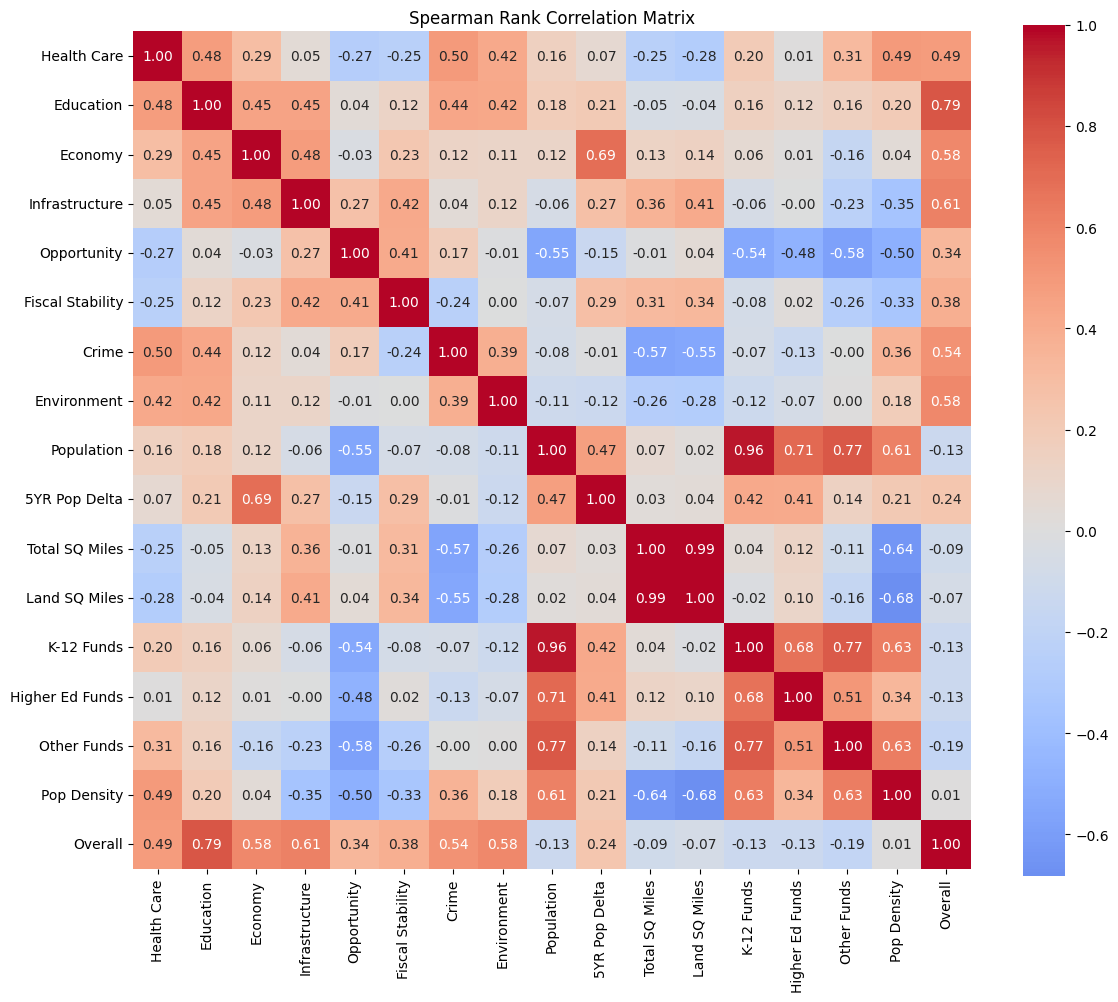

In [20]:
#ToDo: Create a correlation matrix
numeric_cols = merged.select_dtypes(include=[np.number]).columns # Identify numerical columns
spearman_corr = merged[numeric_cols].corr(method='spearman') # Calculate Spearman rank correlation for all numeric columns

# Creating a correlation matrix with heatmap (redder = more positive correlative; bluer = more negative)
plt.figure(figsize=(12, 10)) # Setting a readable figsize
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('Spearman Rank Correlation Matrix')
plt.tight_layout()
plt.show();

<div class="alert alert-block alert-success"><b>Problem 5 (2 pts.)</b>: 
   
1. Use a `Markdown` cell to discuss the highest (positive) correlation with `Population` variable. What does this suggest?
2. Use a `Markdown` cell to discuss the lowest (negative) correlation with `Population` variable. What does this suggest?

</div>

### Highest (positive) Correlation with Population
`K-12 Funds` (i.e., ELSED_TOT) has the highest correlation to `Population` at 0.96 (96%). This suggests that K-12 education funding rises and falls in tandem with population levels in the states. This makes intuitive sense as larger states will tend to have larger student populations enrolled in elementary through high schools. It also suggests that population is an excellent factor to predict how much the state will spend on K-12 education. 

### Lowest (negative) Correlation with Population
`Opportunity` has the lowest correlation to `Population` at -0.55 (-55%). This suggests that opportunity scores move opposite of changes to population levels in the states. This indicates that more populated states have more challenges maintaining affordability, equality, and economic opportunity levels. This makes intuitive sense as larger populations can put pressure on limited federal funding, increase demand for finite resources like housing, and even decrease fairness in the job market due to immense competition. This could lead to lower `Oppportunity` scores for states like New York & California. 

<div class="alert alert-block alert-success"><b>Problem 6 (3 pts.)</b>: 
 
Use the correlation matrix for the next three questions. Use a `Markdown` cell for your answers.
    
1. We had a hunch that the states with the higher `5 YR Delta` will have a higher `Economy` score. Is this supported?
2. Discuss the relationship between the States `Total SQ Miles` and the Environment scores.
3. What does the correlation between `Pop Density` and `Crime`?

</div>

### 1. Relationship between 5 YR Pop Delta and Economy Score

Yes, this hunch is strongly supported as the correlation between `5YR Pop Delta` and `Economy` is +0.69 (69%). Our hypothesis is that higher growth rates have better economic performance, leading to a higher `Economy` score. This makes sense as this is a virtuous cycle: people migrate to states with strong economic growth and strong economic requires more people. According the US News Report's methodology section, Economy refers to business environment (business creation, company headquartering etc.), employment (growth in jobs, labor force participation etc.) and growth (net migration, GDP growth etc.) which is intuitively speaking influenced by growth in population. 

*One caveat though: the economy score already considers net migration which is related to population deltas, so it might be a redundant comparison to make.*

### 2. Relationship between Total SQ Miles and Environment Scores
Looking at the correlation between `Total SQ Miles` and `Environment` (-0.26 or -26%), it tells me that the relationship is moderately negative. Larger states tend to have worse environmental scores and vice versa. Per the US News report, `Environment` refers to air & water quality and pollution metrics. This relationship is telling us that larger states (by geographic area) could have issue managing their environmental concerns. Larger states tend to have higher industrial activity and also may struggle with actually monitoring and enforcing regulations. 

### 3. Relationship between Pop Density and Crime
The correlation between `Pop Density` and `Crime` is +0.36 (+36%). This is a somewhat positive correlation meaning that crime scores increase as population density increases. Here, `Crime` does not refer to crime levels but correction outcomes and public safety levels. So, it actually means that the larger states do better on crime measures than smaller states. These seems counter-intuitive to me as I would expect more density to increase causes for social friction and crime. However, more dense states may also have better police-to-public ratios, better funding, and more comprehensive social services that improve correction outcomes. 

### Gradient heatmaps

The gradient heatmap is a great way to look for patterns in the data. The gradient of colors helps to draw your attention of numbers that go against what may be expected.

Observations from the heatmap below:
- Louisiana looks to be very poor in every category
- Michigan is poor in `Education` and yet has a `K-12 Funds` budget two to six times the other states in the bottom ten spots; this is probably due to their large population.

In [21]:
# Show the bottom 10 states based on Overall score
overallBot10 = merged.sort_values(by = ['Overall'], ascending = True)[:10]
overallBot10.style.background_gradient(cmap = 'Greens')

,State,Health Care,Education,Economy,Infrastructure,Opportunity,Fiscal Stability,Crime,Environment,Population,5YR Pop Delta,Total SQ Miles,Land SQ Miles,K-12 Funds,Higher Ed Funds,Other Funds,Pop Density,Overall
49,Louisiana,5,4,2,2,7,10,1,2,4597740,-54561,52378,43204,8388.000000,3779.000000,14747.000000,106.419313,4.120000
48,New Mexico,13,1,6,7,15,18,3,19,2130256,11650,121590,121298,4890.000000,4269.000000,5806.000000,17.562169,10.250000
47,Mississippi,1,16,1,3,16,6,26,31,2943045,-15491,48432,46923,4998.000000,5069.000000,10600.000000,62.720734,12.500000
46,Arkansas,4,13,11,9,22,24,2,16,3088354,73808,53179,52035,4839.000000,4678.000000,11449.000000,59.351475,12.620000
44,Alaska,24,5,5,5,30,30,7,7,740133,7116,665384,570641,1963.000000,1006.000000,6871.000000,1.297020,14.120000
45,West Virginia,3,3,3,1,35,33,30,12,1769979,-21667,24230,24038,3192.000000,2100.000000,7096.000000,73.632540,15.000000
43,Alabama,7,6,19,15,20,32,23,4,5157699,124605,52420,50645,11296.000000,7763.000000,7326.000000,101.840241,15.750000
41,Michigan,22,10,23,10,24,19,13,21,10140459,67756,96714,56539,21862.000000,3203.000000,21477.000000,179.353349,17.750000
42,Oklahoma,2,2,28,34,25,25,15,13,4095393,129978,69899,68595,4963.000000,3901.000000,4858.000000,59.703958,18.000000
40,South Carolina,21,9,29,14,9,23,8,32,5478831,346582,32020,30061,7798.000000,7644.000000,10138.000000,182.257111,18.120000


<div class="alert alert-block alert-success"><b>Problem 7 (3 pts.)</b>: 
   
1. Create a gradient heatmap of the **top** 10 states in any category you choose. Consider trying a different color.
2. Use a `Markdown` cell to comment on at least 3 observations of the results.

</div>

<div class="alert alert-block alert-success"><b>Problem 7 (part 1)</b>: 
   
Create a gradient heatmap of the **top** 10 states in any category you choose. Consider trying a different color.
</div>

In [22]:
#ToDo: Create a gradient heatmap for TOP 10 in some category
# Top 10 States by Health Care
economytop10 = merged.nlargest(10, 'Health Care')
economytop10.style.background_gradient(cmap='Reds')

,State,Health Care,Education,Economy,Infrastructure,Opportunity,Fiscal Stability,Crime,Environment,Population,5YR Pop Delta,Total SQ Miles,Land SQ Miles,K-12 Funds,Higher Ed Funds,Other Funds,Pop Density,Overall
33,Hawaii,50,19,9,4,10,5,41,50,1446146,-5106,10932,6423,3078.000000,816.000000,10750.000000,225.151175,23.500000
9,Massachusetts,49,48,43,12,5,12,47,44,7136171,141573,10554,7800,13325.000000,1929.000000,37358.000000,914.893718,32.500000
19,Connecticut,48,43,34,23,4,2,45,30,3675069,95151,5543,4842,6500.000000,3696.000000,17715.000000,758.998141,28.620000
13,New Jersey,47,47,27,35,8,3,46,27,9500851,228057,8723,7354,22776.000000,8002.000000,40838.000000,1291.929698,30.000000
25,Rhode Island,46,15,33,6,18,4,44,48,1112308,15778,1545,1034,2128.000000,1431.000000,6105.000000,1075.733075,26.750000
36,California,45,28,17,19,1,9,17,18,39431263,-90695,163695,155779,82522.000000,28918.000000,157080.000000,253.123097,19.250000
21,Maryland,44,31,20,18,21,22,33,45,6263220,85285,12406,9707,11287.000000,8754.000000,22773.000000,645.227156,29.250000
22,New York,43,39,7,22,2,28,27,46,19867248,-237923,54555,47126,45012.000000,12850.000000,67979.000000,421.577219,26.750000
20,Delaware,42,18,30,25,38,47,19,8,1051917,59989,2489,1949,3740.000000,595.000000,6797.000000,539.721396,28.380000
7,Washington,41,38,37,44,14,37,12,40,7958180,230971,71298,66456,17066.000000,8561.000000,14238.000000,119.751114,32.880000


<div class="alert alert-block alert-success"><b>Problem 7 (part 2)</b>: 
   
Use a `Markdown` cell to comment on at least 3 observations of the results.
</div>

### Observations: Top 10 States by Health Care scores
These are interesting scores across the board. 

1. **Hawaii**: The state leads in `Health Care` (50) but it has terrible `Economy` (9) and `Infrastructure` (4) scores. This is intriguing as I would expect strong infrastructure to be a pre-requisite for great health care but it seems that strong policy, good environment, and great crime ratings are far more important. 

2. **Massachusetts and Connecticut**: Both these states are well-rounded performers with high `Health Care`, `Education` and `Economy` scores. My intuition is that these states benefit from compounding strengths rather than excelling in just one area.

3. **California**: The Golden State is top 10 for `Health Care` (45) even with a negative `5YR Pop Delta` (-90,695). This means that people are leaving California even though its health care is among the strongest in the US. This tells us that factors like cost of living, housing, or opportunity may have more overbearing influence on people leaving California than quality health care can make them stay.

### Binning values

Binning values allows you to create segments or groups within your data.
- `pd.cut` will create bins of equal width (range of values).  The bins will be based on quantiles making sure that each bin will have roughly an equal range but not necessarily the same number of data points.
- `pd.qcut` creates bins based on quantiles ensuring that each bin will have approximately an equal number of rows.

__[pandas cut](https://pandas.pydata.org/docs/reference/api/pandas.cut.html)__

__[pandas qcut](http://pandas.pydata.org/docs/reference/api/pandas.qcut.html)__

If we look at `cut`, this gives us an uneven split. Whereas, `qcut` gives us groups with similar size.

In [23]:
merged['Pop Bin'] = pd.cut(merged['Population'], 3)
merged['Pop Bin'].value_counts()

Pop Bin
(548774.355, 13535499.667]      46
(13535499.667, 26483381.333]     2
(26483381.333, 39431263.0]       2
Name: count, dtype: int64

In [24]:
merged['Pop BinQ'] = pd.qcut(merged['Population'], 3,
                    labels = [ 'Small Pop', 'Med Pop', 'Large Pop'])
merged['Pop BinQ'].value_counts()

Pop BinQ
Small Pop    17
Large Pop    17
Med Pop      16
Name: count, dtype: int64

The combination of a `groupby` and a `gradient heatmap` shows us where there are differences between the three groups.  

- The Large Pop states perform better at health care, eduation and the economy
- The Med Pop states performed better at Infrastructure
- The Small Pop states performed better at Opportunity, Crime and Environment

In [25]:
qcol = ['Health Care', 'Education', 'Economy', 'Infrastructure', 'Opportunity',
       'Fiscal Stability', 'Crime', 'Environment', 'Pop BinQ']

temp = merged[qcol]
temp2 = temp.groupby('Pop BinQ').mean(numeric_only = True)
temp2.style.background_gradient(cmap = 'Reds')

,Health Care,Education,Economy,Infrastructure,Opportunity,Fiscal Stability,Crime,Environment
Pop BinQ,,,,,,,,
Small Pop,24.117647,22.823529,22.941176,24.411765,34.705882,25.764706,28.882353,29.117647
Med Pop,22.687500,24.062500,24.562500,27.437500,24.250000,25.937500,20.250000,23.375000
Large Pop,29.529412,29.529412,28.941176,24.764706,17.470588,24.823529,27.058824,23.882353


### Stacked barchart

This stacked barchart below is using the data from the bottom 10 States for `Overall` score. You would use a stacked barchart whenever you want to see how a total is broken down into parts.  Below we can see out of the states we chose to plot that South Carolina has the highest cumulative scores and you can see that the Economy makes up the majority of the total score.

__[Stacked Bar Plot](https://www.geeksforgeeks.org/create-a-stacked-bar-plot-in-matplotlib/)__

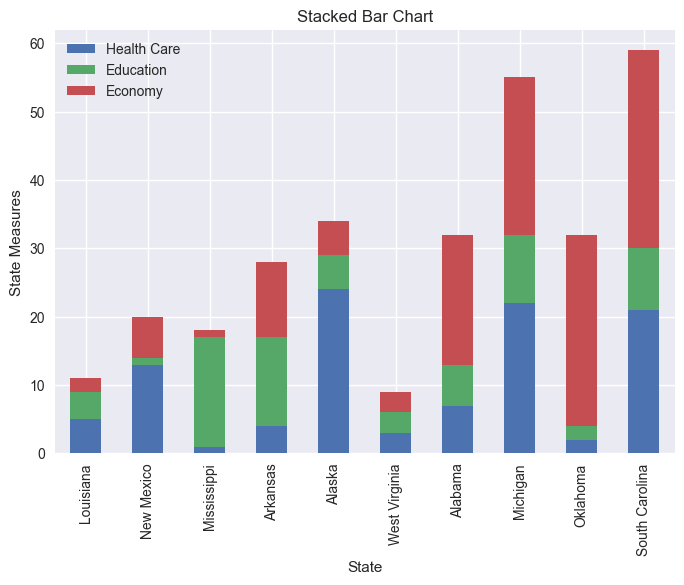

In [26]:
subBot10 = overallBot10[['State','Health Care', 'Education', 'Economy']]
plt.style.use('seaborn-v0_8')
subBot10.plot(x = 'State', kind = 'bar', stacked = True, title = 'Stacked Bar Chart',
                ylabel = 'State Measures')
ax.legend
plt.show();

### Horizontal barchart with Overall score

When you are in the clean/prep/inspect phase of looking at data, there will be lots of ways to look at data. This horizontal barchart is showing just one variable - Overall score.  This allows you to scroll down and easily see where States fall in line. This is a long scroll though that can be conducive to investigating data, but not a visual that you would use in a final report.

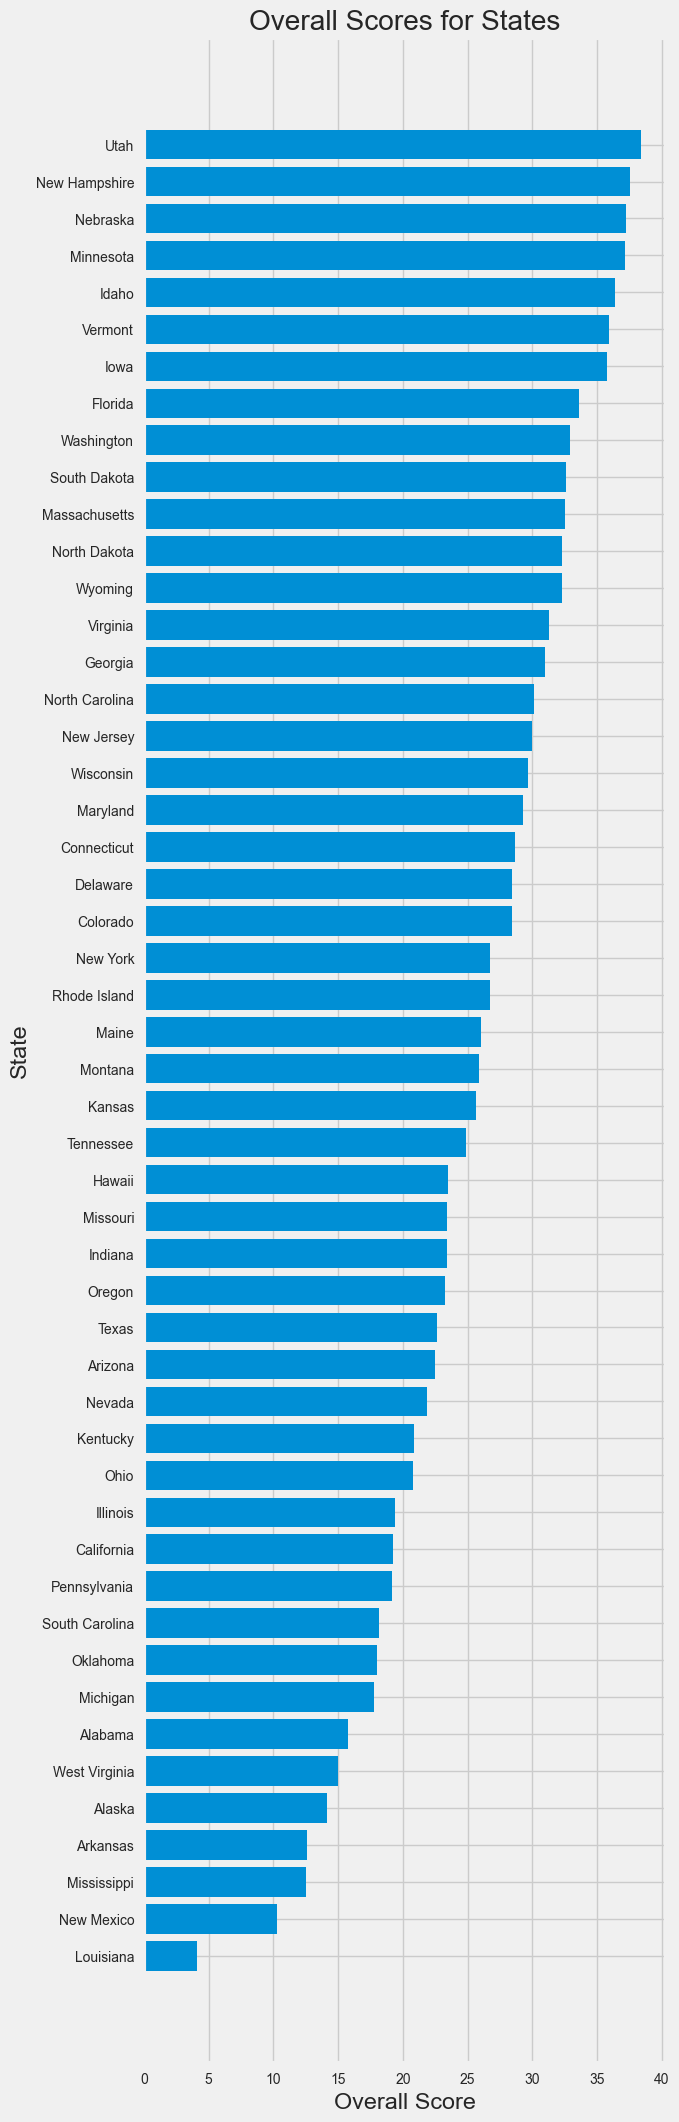

In [27]:
plt.style.use('fivethirtyeight')
fig, ax = plt.subplots(figsize = (6, 25))

subsetall = merged[['State', 'Overall']]

subsetall = subsetall.sort_values(by = 'Overall')

ax.barh(subsetall['State'], subsetall['Overall'], align = 'center')

ax.set(xlabel = 'Overall Score', ylabel = 'State',
       title = 'Overall Scores for States');

### Example of bad graph

- There is no header
- There is no legend
- There is no x or y axis label
- The state names on the x axis are all running together; this can be fixed by rotating the axis label

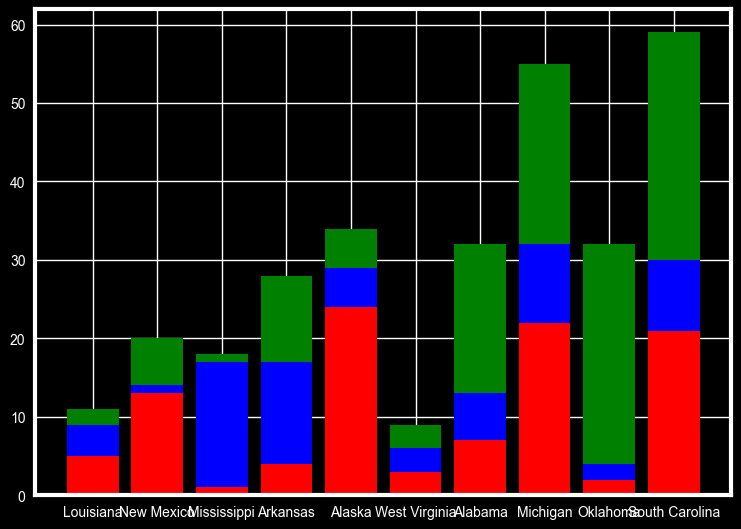

In [28]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize = (8, 6))

x = subBot10['State']
y1 = subBot10['Health Care']
y2 = subBot10['Education']
y3 = subBot10['Economy']

plt.bar(x, y1, color = 'r');
plt.bar(x, y2, bottom = y1, color = 'b');
plt.bar(x, y3, bottom = y1+y2, color = 'g');

### Horizontal barchart

- Note that there is no header and the legend is hard to read since it is in white font
- The horizontal barchart has the same use as the normal barchart but flipped on the side. Some may  find this easier to read.

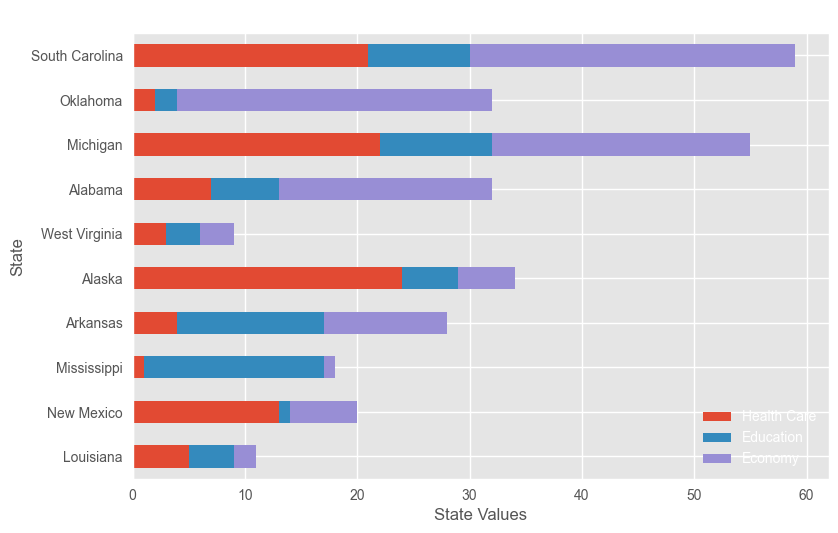

In [29]:
plt.style.use('ggplot')

subBot10.plot(x = 'State', kind = 'barh', stacked = True, title = 'State Values')
plt.xlabel('State Values')
plt.show();

### Plotting with three variables

The plotly bubble chart below shows `Education`, `Economy` and `Population`. The x-axis represents Education, the y-axis represents Economy, and the size of each bubble corresponds tothe state's population.

**Hover over each circle** to see the three values plotted for that state.

Interpretation of chart:
- Keep in mind that these are the bottom 10 states in overall score
- As indicated by the size of the bubble, Michigan is the largest state in population
- The state worse in both measures shown, Economy and Opportunity, is Louisana in the lower left hand corner
- West Virginia has the higheset score in Opportunity but very low in the Economy

__[Bubble Charts](https://plotly.com/python/bubble-charts/)__

In [30]:
# Set theme back to default
sns.set_theme()

subBot10 = overallBot10[['State','Opportunity', 'Education', 'Economy', 'Population', 'K-12 Funds']]

# Bubble chart
fig = px.scatter(subBot10, x = "Opportunity", y = "Economy", color = 'State', 
                 size = 'Population', size_max = 60, text = 'State',
        title='Economy, Opportunity and Population for 10 Bottom States Overall', 
                 color_discrete_sequence = px.colors.qualitative.Bold)
fig.update_layout(xaxis_title = 'Opportunity',
                 yaxis_title = 'Economy');
fig.show()

<div class="alert alert-block alert-success"><b>Problem 8 (6 pts.)</b>: 
   
1. Create a subset of data by selecting either the **top 10 or bottom 10 states** based on any field of your choice.  
   - Along with `State`, select **three additional fields** to include in your chart.  
2. Plot a bubble chart using the selected data.  
3. In a `Markdown` cell, provide an explanation of what the bubble chart represents, including insights from the data.  

</div>

<div class="alert alert-block alert-success"><b>Problem 8 (part 1)</b>: 
<br><br>
    
Create a subset of data by selecting either the **top 10 or bottom 10 states** based on any field of your choice. Along with `State`, select **three additional fields** to include in your chart.  
</div>

In [31]:
#ToDo: Create a subset of data with select fields. Answers will vary by student
# Top 10 states by Economy score
economyTop10 = merged.nlargest(10, 'Economy')
subTop10 = economyTop10[['State', 'Education', 'Population', 'Economy']]
subTop10

,State,Education,Population,Economy
8,Florida,50,23372215,50
4,Idaho,33,2001619,49
0,Utah,49,3503613,48
15,Colorado,46,5957493,47
32,Nevada,14,3267467,46
28,Texas,22,31290831,45
1,New Hampshire,42,1409032,44
9,Massachusetts,48,7136171,43
23,Montana,29,1137233,42
31,Arizona,7,7582384,41


<div class="alert alert-block alert-success"><b>Problem 8 (part 2)</b>: 
<br><br>
Plot a bubble chart using the selected data.  
</div>

In [32]:
#ToDo: Create a bubble chart with your data
fig = px.scatter(subTop10,
                 x='Education',
                 y='Economy',
                 color='State',
                 size='Population',
                 size_max=60,
                 text='State',
                 title='Education, Economy, and Population for Top 10 States by Economy Score',
                 color_discrete_sequence=px.colors.qualitative.Bold)

fig.update_layout(xaxis_title='Education Score',
                  yaxis_title='Economy Score')
fig.show()

<div class="alert alert-block alert-success"><b>Problem 8 (6 pts.)</b>: 
<br><br>   
    
In a `Markdown` cell, provide an explanation of what the bubble chart represents, including insights from the data.  

</div>

### Bubble Chart: Education, Economy, and Population — Top 10 States by Economy Score

I elected to plot a bubble chart, with the `Education` score as the x-axis and the `Economy` score as the y-axis, for the top 10 states ranked by `Economy` score. Each bubble's size indicates the state's population, with larger bubbles indicating more populous states.

<u> Insights: </u>

1. Florida leads in both `Economy` (50) and `Education` (50), yet is also the second most populous state in this group at 23.4 million. This tells me that a large population is not a hindrance to achieving high economy & education scores. Florida has managed to top two crucial dimensions simultaneously, becoming a standout performer.

2. Another insight is that a high `Economy` score does not require a high Education score. This is plainly seen in the case of Nevada (`Economy`: 46) and Texas (`Economy`: 45) as they both have low `Education` scores (14 and 22 respectively), but are in the top 5 for `Economy`. This tells us that economic power is not just driven by education but also by other factors like low taxes (both states have no income tax) and business-friendly policies.

3. Thirdly, Texas has the largest population (31.3 million) but a moderate `Education` score of 22. It has the highest population of the top 10 and a strong `Economy` score of 45, which suggests that a strong economy and large population cannot give a state better educational outcomes. This can be seen with a state like New Hampshire, which has a population of 1.4 million but has an `Education` score of 42.

### Seaborn pairplot with hue

Below is sample code of the Seaborn Pairplot using color to represent the three different groups we created.

- Remember that we created the bins based on `Population` so any plot with population will have 3 clear groupings.
- And K-12 Funds has a .96 correlation with population so plots with this variable will also have pretty clear groups.
- When we look at the `Overall` plot with `Education` there is not clear groupings of our three bins.

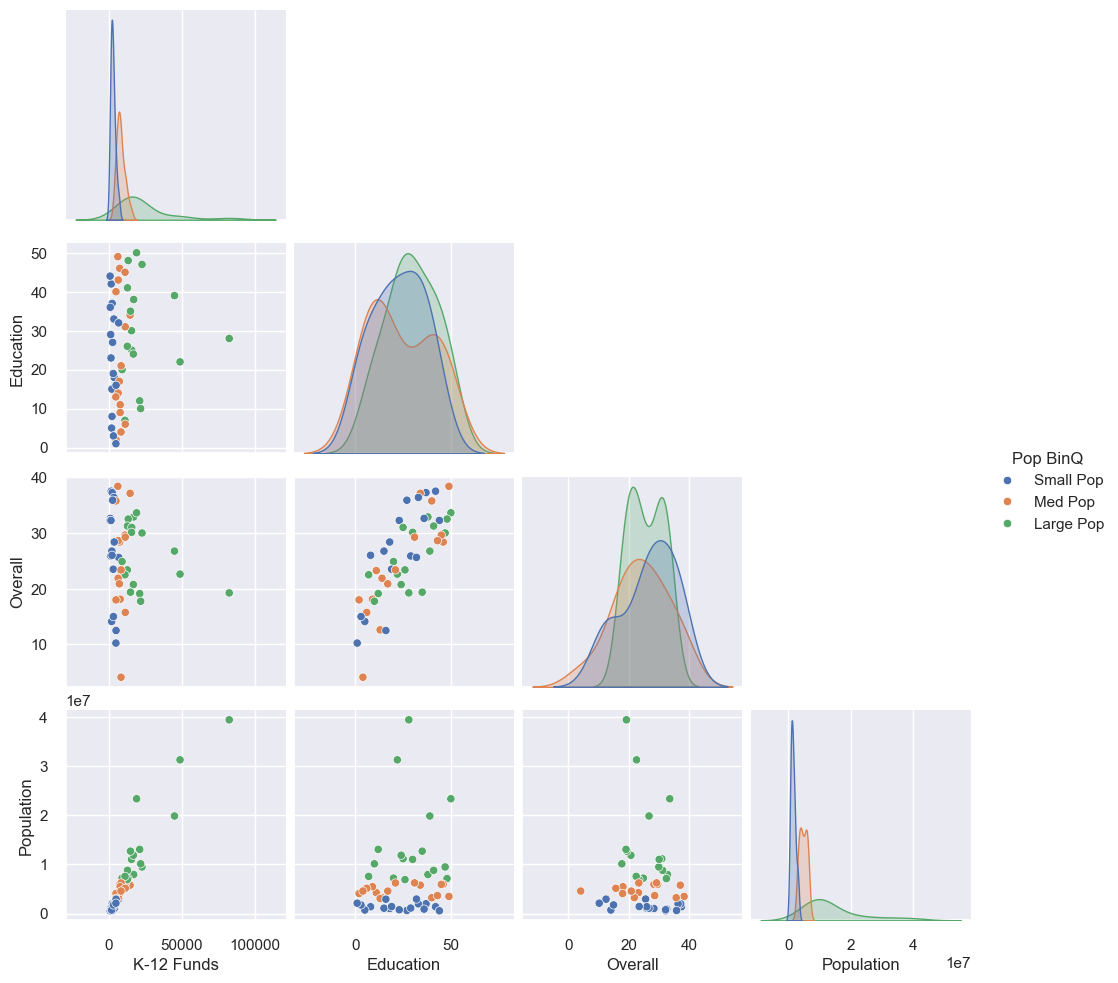

In [33]:
sns.pairplot(merged, hue = 'Pop BinQ', kind = 'scatter', corner = True,
            vars = ['K-12 Funds', 'Education','Overall', 'Population'])